# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
- Plain linear models assume the response is a continuous Gaussian-ish number, which is usually used for things like house prices. However, when we're trying to predict probabilities, then we need to use GLMs. Activation functions transform outputs so we can model things like probabilites or counts. Therefore, activation functions makes the outputs much more flexible.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
- Binary and categorical cross entropy are effective loss functions because it's just the negative log-likelihood of a Bernoulli model. So if we minimize the negative log-likelihood, we are actually maximizing the log-likelihood. 


3. True or false, and explain: Logistic regression is a linear model.
- True, the parameters are linear, but the output is just passed through a nonlinear sigmoid that converts the output to nonlinear possibilities


4. True or false, and explain: Logistic regression cannot be used for classification.
- False, it is mainly used for classification. It gives us a probability, we threshold it, then we have a classifier

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
- No, not on the probabilty scale. A 1 unit change will shift the log-odds and multiply the odds. 


6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
- False, the features in logistic regression are linear. Feature engineering is how you inject nonlinearity

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.
- False, they're used for different things, OLS for continuous responses and logistic for binary responses. 

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv("data/data.csv", sep=";")

cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target",
]
df = df[cols]

#check missing values
print("Missing values per column:")
print(df.isna().sum())
df = df.dropna()

df["dropout"] = (df["Target"] == "Dropout").astype(int)


Missing values per column:
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64



2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?


In [ ]:
features = ["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]
X = df[features].values
y = df["dropout"].values

logit = LogisticRegression(max_iter=1000)
logit.fit(X, y)

print("\nLogistic regression coefficients:")
for name, coef in zip(features, logit.coef_[0]):
    print(f"{name}: {coef:+.4f} (odds ratio: {np.exp(coef):.3f})")
print(f"Intercept: {logit.intercept_[0]:+.4f}")


Logistic regression coefficients:
  Debtor: +0.5306  (odds ratio: 1.700)
  Tuition fees up to date: -2.5565  (odds ratio: 0.078)
  Scholarship holder: -1.2274  (odds ratio: 0.293)
  Age at enrollment: +0.0499  (odds ratio: 1.051)
  Intercept: +0.4857


Being a debtor and being older at enrollment yields a higher dropout rate. Being up to date on tuition and holding a scholarship yields a lower dropout rate. 


3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

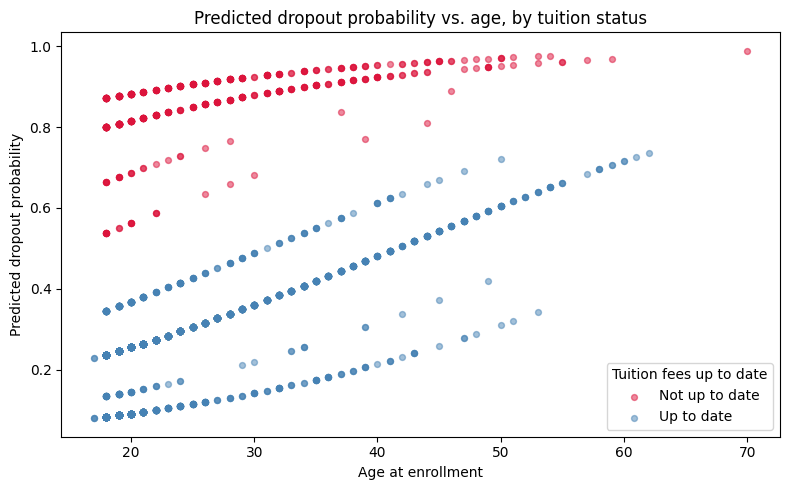

In [16]:
proba = logit.predict_proba(X)[:, 1]
df["pred_dropout"] = proba

fig, ax = plt.subplots(figsize=(8, 5))
for val, color, label in [(0, "crimson", "Not up to date"), (1, "steelblue", "Up to date")]:
    mask = df["Tuition fees up to date"] == val
    ax.scatter(df.loc[mask, "Age at enrollment"], df.loc[mask, "pred_dropout"],
               alpha=0.5, s=18, c=color, label=label)
ax.set_xlabel("Age at enrollment")
ax.set_ylabel("Predicted dropout probability")
ax.set_title("Predicted dropout probability vs. age, by tuition status")
ax.legend(title="Tuition fees up to date")
plt.tight_layout()
plt.savefig("q3_scatter.png", dpi=120)
plt.show()

Being up to date seems to reduce predicted dropout probability the most in the 20's. Being up to date on tuition fees can reduce dropout probaility by at least half. 


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?


In [17]:
preds = logit.predict(X)
cm = confusion_matrix(y, preds)
acc = accuracy_score(y, preds)
print(f"\nConfusion matrix (rows=true, cols=pred):\n{cm}")
print(f"Accuracy: {acc:.4f}")


Confusion matrix (rows=true, cols=pred):
[[2841  162]
 [ 891  530]]
Accuracy: 0.7620



5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.


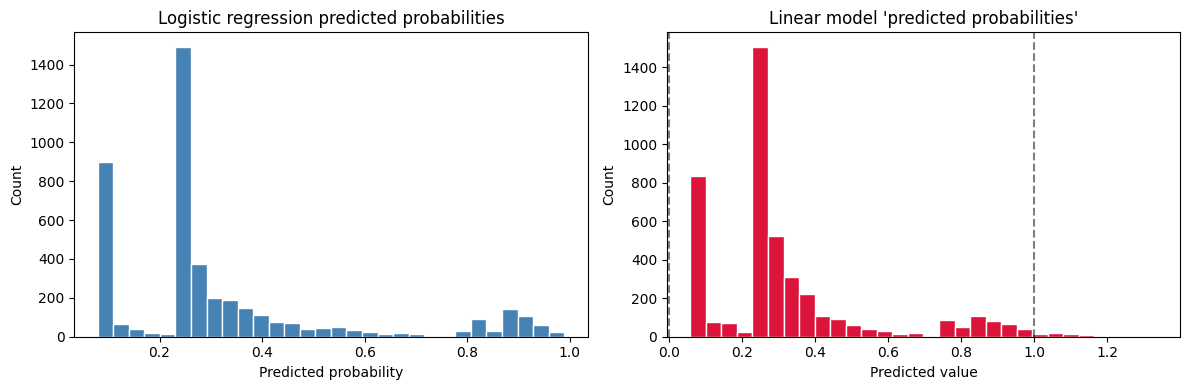


Linear model predictions outside [0,1]: 57 of 4424
Linear model range: [0.058, 1.335]


In [18]:
lin = LinearRegression()
lin.fit(X, y)
lin_preds = lin.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(proba, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Logistic regression predicted probabilities")
axes[0].set_xlabel("Predicted probability"); axes[0].set_ylabel("Count")
axes[1].hist(lin_preds, bins=30, color="crimson", edgecolor="white")
axes[1].axvline(0, linestyle="--", color="black", alpha=0.5)
axes[1].axvline(1, linestyle="--", color="black", alpha=0.5)
axes[1].set_title("Linear model 'predicted probabilities'")
axes[1].set_xlabel("Predicted value"); axes[1].set_ylabel("Count")
plt.tight_layout()
plt.savefig("q5_hist.png", dpi=120)
plt.show()

print(f"\nLinear model predictions outside [0,1]: "
      f"{((lin_preds < 0) | (lin_preds > 1)).sum()} of {len(lin_preds)}")
print(f"Linear model range: [{lin_preds.min():.3f}, {lin_preds.max():.3f}]")

Both models show similar performance, but the linear model has slightly higher predicted values. 


5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?


The student who is a debtor, not up to date on tuition, not a scholarship holder, and older at enrollment are the most at-risk of dropping out. Some interventions that can help at-risk students stay enrolled include things like providing childcare for those with children (because age plays a large factor in dropping out, and thus we can assume that children play a role) or expanding giving out scholarships. 


6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [19]:
features_m = ["Debtor", "Tuition fees up to date", "Curricular units 1st sem (approved)"]
Xm = df[features_m].values
ym = df["Target"].values

multi = LogisticRegression(max_iter=1000)  # multinomial is default in modern sklearn
multi.fit(Xm, ym)
preds_m = multi.predict(Xm)
proba_m = multi.predict_proba(Xm)

print(f"\nMultinomial classes: {multi.classes_}")
print(f"Unique hard predictions: {np.unique(preds_m)}")
cm_m = confusion_matrix(ym, preds_m, labels=multi.classes_)
print(f"Confusion matrix (rows=true, cols=pred, order={list(multi.classes_)}):\n{cm_m}")
print(f"Multinomial accuracy: {accuracy_score(ym, preds_m):.4f}")

# Are any classes ever the argmax? Are they ever predicted as a probability at all?
print("\nMax predicted probability per class across all rows:")
for i, cls in enumerate(multi.classes_):
    print(f"  {cls}: max proba = {proba_m[:, i].max():.3f}, "
          f"mean proba = {proba_m[:, i].mean():.3f}")


Multinomial classes: ['Dropout' 'Enrolled' 'Graduate']
Unique hard predictions: ['Dropout' 'Graduate']
Confusion matrix (rows=true, cols=pred, order=['Dropout', 'Enrolled', 'Graduate']):
[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
Multinomial accuracy: 0.7046

Max predicted probability per class across all rows:
  Dropout: max proba = 0.960, mean proba = 0.321
  Enrolled: max proba = 0.328, mean proba = 0.179
  Graduate: max proba = 1.000, mean proba = 0.499


The hard classification can't predict enrolled, but it can predict dropout and graduate well with 96% and 100% accuracy respectively. The predicted probabilities are represented in the confusion matrix above. 

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.


In [24]:
df = pd.read_csv("data/cirrhosis.csv")
 
cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
df = df[cols]
 
print("Missing values per column:")
print(df.isna().sum())

#drop any rows missing values in columns we use. preserves the randomized comparison and keeps the analysis honest.
df = df.dropna()

#encode: survival = 1 if alive (C or CL), 0 if dead (D)
df["survived"] = (df["Status"] != "D").astype(int)
 
#encode Edema as ordinal: N < S < Y (increasing severity)
edema_map = {"N": 0, "S": 1, "Y": 2}
df["edema_ord"] = df["Edema"].map(edema_map)
 
#encode Drug as binary: 1 if D-penicillamine, 0 if Placebo
df["drug_bin"] = (df["Drug"] == "D-penicillamine").astype(int)

Missing values per column:
Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64



2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?


In [25]:
features = ["edema_ord", "drug_bin", "Bilirubin"]
X = df[features].values
y = df["survived"].values
 
logit = LogisticRegression(max_iter=1000)
logit.fit(X, y)
 
print("\nLogistic regression (survival) coefficients:")
for name, coef in zip(features, logit.coef_[0]):
    print(f"  {name}: {coef:+.4f}  (odds ratio: {np.exp(coef):.3f})")
print(f"  Intercept: {logit.intercept_[0]:+.4f}")


Logistic regression (survival) coefficients:
  edema_ord: -0.9153  (odds ratio: 0.400)
  drug_bin: -0.2235  (odds ratio: 0.800)
  Bilirubin: -0.3486  (odds ratio: 0.706)
  Intercept: +1.6498


The coefficient on drug is slightly negative so D-penicillamine is associated with slightly lower survivability odds than placebo. Higher bilirubin predicts a lower survival rate. With edema, survival rates drop significantly. 


3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

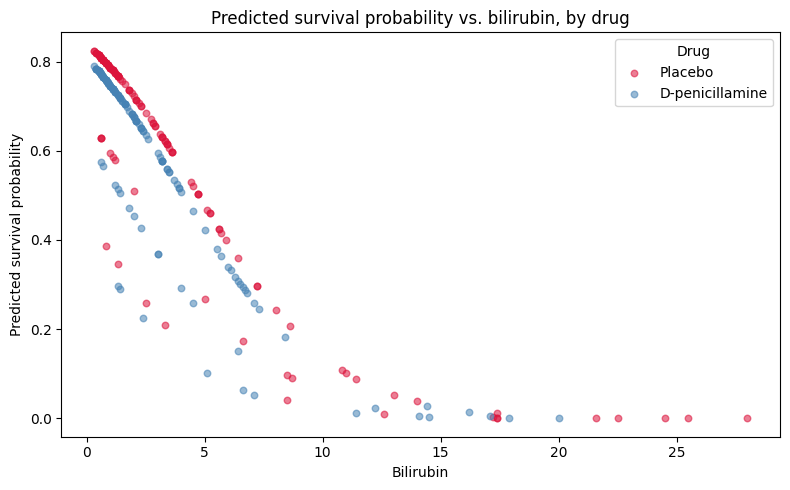


Average change in survival probability from taking drug: -0.0404

Drug benefit (P_drug - P_placebo) by bilirubin range:
bili_bin
(0, 1]     -0.038573
(1, 2]     -0.044549
(2, 5]     -0.051472
(5, 10]    -0.041455
(10, 30]   -0.004224
Name: _gap, dtype: float64


In [28]:
proba = logit.predict_proba(X)[:, 1]
df["pred_survive"] = proba
 
fig, ax = plt.subplots(figsize=(8, 5))
for val, color, label in [(0, "crimson", "Placebo"), (1, "steelblue", "D-penicillamine")]:
    mask = df["drug_bin"] == val
    ax.scatter(df.loc[mask, "Bilirubin"], df.loc[mask, "pred_survive"],
               alpha=0.55, s=22, c=color, label=label)
ax.set_xlabel("Bilirubin")
ax.set_ylabel("Predicted survival probability")
ax.set_title("Predicted survival probability vs. bilirubin, by drug")
ax.legend(title="Drug")
plt.tight_layout()
plt.show()

X_drug = X.copy(); X_drug[:, 1] = 1
X_placebo = X.copy(); X_placebo[:, 1] = 0
avg_effect = logit.predict_proba(X_drug)[:, 1].mean() - logit.predict_proba(X_placebo)[:, 1].mean()
print(f"\nAverage change in survival probability from taking drug: {avg_effect:+.4f}")
 
df["_p_drug"] = logit.predict_proba(X_drug)[:, 1]
df["_p_placebo"] = logit.predict_proba(X_placebo)[:, 1]
df["_gap"] = df["_p_drug"] - df["_p_placebo"]
df["bili_bin"] = pd.cut(df["Bilirubin"], bins=[0, 1, 2, 5, 10, 30])
print("\nDrug benefit (P_drug - P_placebo) by bilirubin range:")
print(df.groupby("bili_bin", observed=True)["_gap"].mean())
 

The drug does not increase predicted survival at any value of bilirubin. In fact, because the drug coefficient is negative, much of the drug group sits slightly below placebo .


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?


In [29]:
preds = logit.predict(X)
cm = confusion_matrix(y, preds)
acc = accuracy_score(y, preds)
print(f"\nConfusion matrix (rows=true, cols=pred; 0=died, 1=survived):\n{cm}")
print(f"Accuracy: {acc:.4f}")


Confusion matrix (rows=true, cols=pred; 0=died, 1=survived):
[[ 60  65]
 [ 14 173]]
Accuracy: 0.7468


Stronger on survivors and weaker on deaths.


5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

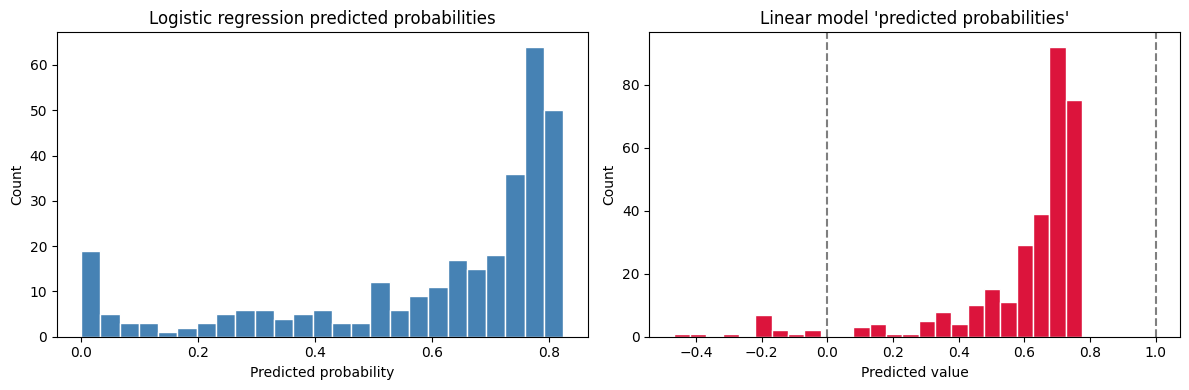


Linear model predictions outside [0,1]: 15 of 312
Linear model range: [-0.468, 0.776]


In [31]:
lin = LinearRegression()
lin.fit(X, y)
lin_preds = lin.predict(X)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(proba, bins=25, color="steelblue", edgecolor="white")
axes[0].set_title("Logistic regression predicted probabilities")
axes[0].set_xlabel("Predicted probability"); axes[0].set_ylabel("Count")
axes[1].hist(lin_preds, bins=25, color="crimson", edgecolor="white")
axes[1].axvline(0, linestyle="--", color="black", alpha=0.5)
axes[1].axvline(1, linestyle="--", color="black", alpha=0.5)
axes[1].set_title("Linear model 'predicted probabilities'")
axes[1].set_xlabel("Predicted value"); axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()
 
print(f"\nLinear model predictions outside [0,1]: "
      f"{((lin_preds < 0) | (lin_preds > 1)).sum()} of {len(lin_preds)}")
print(f"Linear model range: [{lin_preds.min():.3f}, {lin_preds.max():.3f}]")

All of the logistic predictions are within [0,1] while the linear model has a range of [-0.468, 0.776], a kind of awkward range. Logistic is the better choice here because the probabilities are valid and the shape is more useful. 


6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [32]:
features_s = ["edema_ord", "Bilirubin"]
Xs = df[features_s].values
ys = df["Stage"].astype(int).values
 
multi = LogisticRegression(max_iter=1000)
multi.fit(Xs, ys)
preds_s = multi.predict(Xs)
proba_s = multi.predict_proba(Xs)
 
print(f"\nStage classes: {multi.classes_}")
print(f"Unique hard predictions: {np.unique(preds_s)}")
cm_s = confusion_matrix(ys, preds_s, labels=multi.classes_)
print(f"Confusion matrix (rows=true, cols=pred, order={list(multi.classes_)}):\n{cm_s}")
print(f"Stage classification accuracy: {accuracy_score(ys, preds_s):.4f}")
 
print("\nMax predicted probability per stage across all rows:")
for i, cls in enumerate(multi.classes_):
    print(f"  Stage {cls}: max proba = {proba_s[:, i].max():.3f}, "
          f"mean proba = {proba_s[:, i].mean():.3f}")
 
print("\nTrue stage distribution:")
print(pd.Series(ys).value_counts().sort_index())
 


Stage classes: [1 2 3 4]
Unique hard predictions: [3 4]
Confusion matrix (rows=true, cols=pred, order=[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]):
[[  0   0  16   0]
 [  0   0  61   6]
 [  0   0 102  18]
 [  0   0  74  35]]
Stage classification accuracy: 0.4391

Max predicted probability per stage across all rows:
  Stage 1: max proba = 0.111, mean proba = 0.051
  Stage 2: max proba = 0.256, mean proba = 0.215
  Stage 3: max proba = 0.435, mean proba = 0.385
  Stage 4: max proba = 0.867, mean proba = 0.349

True stage distribution:
1     16
2     67
3    120
4    109
Name: count, dtype: int64


The hard classification only ever predicts Stage 3 or Stage 4. Every Stage 1 patient and Stage 2 patient gets misclassified as Stage 3. Stages 1 and 2 get non-zero probability for every patien, so .predict_proba does produce predictions for all four classes but they're just never the largest.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?


The coefficients $b_0, b_1, \ldots, b_K$ of a logistic regression are the weights on the linear predictor $L = b \cdot x = b_0 + \sum_{k=1}^K b_k x_k$, which basically represents the sigmoid function to produce a probability. Each coefficient $b_k$ represents the additional effect of feature $x_k$ on the $\textbf{log-odds}$ of the outcome. On the probability scale, the interpretation is not constant because the effect depends on where you are on the sigmoid curve.


1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?


Given the linear model prediction function, if we take the partial derivative with respect to the $k$-th feature:

$$\frac{\partial \hat{y}}{\partial x_k} = b_k.$$

For a 1-unit change in $x_k$, the prediction changes by exactly $b_k$. This effect is constant as it does not depend on the value of $x_k$ or on any of the other features.


2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

Let $L = b \cdot x$ so that $\hat{p} = \sigma(L) = \dfrac{e^L}{1+e^L}$. By the chain rule,

$$\frac{\partial \hat{p}}{\partial x_k} = \frac{d\sigma}{dL} \cdot \frac{\partial L}{\partial x_k}.$$

Using the hint, $\dfrac{d\sigma}{dL} = \sigma(L)(1 - \sigma(L)) = \hat{p}(1 - \hat{p})$, and $\dfrac{\partial L}{\partial x_k} = b_k$. Therefore

$$\frac{\partial \hat{p}}{\partial x_k} = b_k \cdot \hat{p}(1 - \hat{p}).$$

Yes, the answer depends on $x$ (specifically through $\hat{p}$). This is  different from the linear case in Part 1, where the effect was constant. Here, the effect of $x_k$ on the prediction is largest when $\hat{p} = 0.5$.

The coefficient divided by 4 is a good approximation of the effect when $\hat{p}$ is near $0.5$. 

$$\left.\frac{\partial \hat{p}}{\partial x_k}\right|_{\hat{p}=0.5} = \frac{b_k}{4}.$$




3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

From the given derivation,

$$\log\left(\frac{\hat{p}}{1 - \hat{p}}\right) = b \cdot x = b_0 + \sum_{k=1}^K b_k x_k.$$

The log-odds are a linear function of the features, so

$$\frac{\partial}{\partial x_k} \log\left(\frac{\hat{p}}{1 - \hat{p}}\right) = b_k.$$

A one-unit change in $x_k$ increases the log-odds by exactly $b_k$. It also multiplies the odds themselves by $e^{b_k}$:

$$\frac{\hat{p}_{\text{new}}}{1 - \hat{p}_{\text{new}}} = e^{b_k} \cdot \frac{\hat{p}_{\text{old}}}{1 - \hat{p}_{\text{old}}}.$$

On the log-odds scale, logistic regression recovers the linear interpretation from Part 1 where each coefficient is a constant effect per unit of $x_k$. Logistic regression is linear underneath the link function. The sigmoid only enters when translating log-odds back into probabilities.
